# 100_TEST_: Revenue Forecasting End-to-End Pipeline

Competition-grade, leakage-aware notebook for Datathon 2026 revenue forecasting.

Design:
- Use `sample_submission.csv` only for dates and output schema.
- Build daily features from all raw tables.
- Use target features only after `shift`.
- During CV and test, unknown future auxiliary actuals are replaced by history-only seasonal expectations.
- Validate recursively, so predicted revenue feeds future lags exactly like test-time.
- Train LightGBM, XGBoost, optional CatBoost/Prophet, then optimize blend weights from OOF predictions.


In [7]:
from __future__ import annotations

import gc
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from scipy.optimize import minimize
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from prophet import Prophet
import shap

In [10]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

ROOT = Path.cwd()
# Handle multiple possible locations
if ROOT.name.lower() == "notebooks":
    ROOT = ROOT.parent
elif ROOT.name.lower() == "test" and ROOT.parent.name.lower() == "docs":
    ROOT = ROOT.parent.parent
elif ROOT.name.lower() == "docs":
    ROOT = ROOT.parent

DATA_RAW = ROOT / "data" / "raw"
print("ROOT:", ROOT)
print("DATA_RAW:", DATA_RAW)
print("DATA_RAW exists:", DATA_RAW.exists())

ROOT: d:\datathon\vimchanhxa-datathon
DATA_RAW: d:\datathon\vimchanhxa-datathon\data\raw
DATA_RAW exists: True


## 1. Load data and audit schema

The sample submission target values are placeholders and are never joined into training data.


In [4]:
def load_raw_tables(data_dir: Path = DATA_RAW) -> Dict[str, pd.DataFrame]:
    return {path.stem: pd.read_csv(path) for path in sorted(data_dir.glob("*.csv"))}


def parse_date(df: pd.DataFrame, column: str, new_column: str = "Date") -> pd.DataFrame:
    out = df.copy()
    out[new_column] = pd.to_datetime(out[column], errors="coerce")
    return out


def audit_tables(tables: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for name, df in tables.items():
        date_cols = [c for c in df.columns if "date" in c.lower()]
        rows.append({
            "table": name,
            "rows": len(df),
            "cols": df.shape[1],
            "date_cols": ", ".join(date_cols),
            "columns": ", ".join(df.columns[:12]) + (" ..." if df.shape[1] > 12 else ""),
        })
    return pd.DataFrame(rows).sort_values("table")


In [12]:
# Debug load_raw_tables
print("DATA_RAW:", DATA_RAW)
print("DATA_RAW exists:", DATA_RAW.exists())
print("DATA_RAW is dir:", DATA_RAW.is_dir())

# List files
if DATA_RAW.exists():
    csv_files = list(DATA_RAW.glob("*.csv"))
    print("CSV files found:", len(csv_files))
    for f in csv_files[:5]:
        print(" -", f.name)

# Try loading directly
tables = {}
for path in DATA_RAW.glob("*.csv"):
    tables[path.stem] = pd.read_csv(path)
    
print("Tables loaded:", list(tables.keys()))
print("Number of tables:", len(tables))

if tables:
    schema_audit = audit_tables(tables)
    display(schema_audit)
else:
    print("ERROR: No tables loaded!")

DATA_RAW: d:\datathon\vimchanhxa-datathon\data\raw
DATA_RAW exists: True
DATA_RAW is dir: True
CSV files found: 14
 - customers.csv
 - geography.csv
 - inventory.csv
 - orders.csv
 - order_items.csv
Tables loaded: ['customers', 'geography', 'inventory', 'orders', 'order_items', 'payments', 'products', 'promotions', 'returns', 'reviews', 'sales', 'sample_submission', 'shipments', 'web_traffic']
Number of tables: 14


,table,rows,cols,date_cols,columns
0,customers,121930,7,signup_date,"customer_id, zip, city, signup_date, gender, a..."
1,geography,39948,4,,"zip, city, region, district"
2,inventory,60247,17,snapshot_date,"snapshot_date, product_id, stock_on_hand, unit..."
4,order_items,714669,7,,"order_id, product_id, quantity, unit_price, di..."
3,orders,646945,8,order_date,"order_id, order_date, customer_id, zip, order_..."
5,payments,646945,4,,"order_id, payment_method, payment_value, insta..."
6,products,2412,8,,"product_id, product_name, category, segment, s..."
7,promotions,50,10,"start_date, end_date","promo_id, promo_name, promo_type, discount_val..."
8,returns,39939,7,return_date,"return_id, order_id, product_id, return_date, ..."
9,reviews,113551,7,review_date,"review_id, order_id, product_id, customer_id, ..."


In [ ]:
sales_raw = parse_date(tables["sales"], "Date")
sample_submission = parse_date(tables["sample_submission"], "Date")

print("Sales range:", sales_raw["Date"].min(), "->", sales_raw["Date"].max(), "rows=", len(sales_raw))
print("Test range:", sample_submission["Date"].min(), "->", sample_submission["Date"].max(), "rows=", len(sample_submission))

assert sample_submission["Date"].min() == TEST_START
assert sample_submission["Date"].max() == TEST_END

Sales range: 2012-07-04 00:00:00 -> 2022-12-31 00:00:00 rows= 3833
Test range: 2023-01-01 00:00:00 -> 2024-07-01 00:00:00 rows= 548


## 2. Core utilities and leakage guardrails

For validation folds, data after `train_end` is treated exactly like test: future target is unknown and future auxiliary actuals are replaced with seasonal priors learned from the fold history.


In [14]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def regression_metrics(y_true, y_pred) -> Dict[str, float]:
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
    }


def safe_divide(a, b, eps: float = 1e-9):
    return np.asarray(a, dtype=float) / (np.asarray(b, dtype=float) + eps)


def clip_nonnegative(values):
    return np.maximum(np.asarray(values, dtype=float), 0.0)


def make_calendar(start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    return pd.DataFrame({"Date": pd.date_range(start, end, freq="D")})


def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    d = out["Date"]
    out["dayofweek"] = d.dt.dayofweek.astype(int)
    out["dayofmonth"] = d.dt.day.astype(int)
    out["dayofyear"] = d.dt.dayofyear.astype(int)
    out["weekofyear"] = d.dt.isocalendar().week.astype(int)
    out["month"] = d.dt.month.astype(int)
    out["quarter"] = d.dt.quarter.astype(int)
    out["year"] = d.dt.year.astype(int)
    out["is_weekend"] = out["dayofweek"].isin([5, 6]).astype(int)
    out["is_month_start"] = d.dt.is_month_start.astype(int)
    out["is_month_end"] = d.dt.is_month_end.astype(int)
    out["is_quarter_start"] = d.dt.is_quarter_start.astype(int)
    out["is_quarter_end"] = d.dt.is_quarter_end.astype(int)
    out["days_in_month"] = d.dt.days_in_month.astype(int)
    out["week_of_month"] = ((out["dayofmonth"] - 1) // 7 + 1).astype(int)
    out["days_since_start"] = (d - d.min()).dt.days.astype(int)
    out["is_payday"] = out["dayofmonth"].isin([1, 5, 10, 15, 25, 30, 31]).astype(int)
    out["is_mid_month"] = out["dayofmonth"].between(13, 17).astype(int)
    out["is_year_end_period"] = ((out["month"] == 12) & (out["dayofmonth"] >= 15)).astype(int)
    out["is_year_start_period"] = ((out["month"] == 1) & (out["dayofmonth"] <= 10)).astype(int)
    out["is_1111_proxy"] = ((out["month"] == 11) & (out["dayofmonth"] == 11)).astype(int)
    out["is_black_friday_proxy"] = ((out["month"] == 11) & (out["dayofweek"] == 4) & (out["dayofmonth"].between(23, 29))).astype(int)
    out["is_1212_proxy"] = ((out["month"] == 12) & (out["dayofmonth"] == 12)).astype(int)
    for k in [1, 2, 3]:
        out[f"yearly_sin_{k}"] = np.sin(2 * np.pi * k * out["dayofyear"] / 365.25)
        out[f"yearly_cos_{k}"] = np.cos(2 * np.pi * k * out["dayofyear"] / 365.25)
    for k in [1, 2]:
        out[f"weekly_sin_{k}"] = np.sin(2 * np.pi * k * out["dayofweek"] / 7.0)
        out[f"weekly_cos_{k}"] = np.cos(2 * np.pi * k * out["dayofweek"] / 7.0)
        out[f"monthly_sin_{k}"] = np.sin(2 * np.pi * k * out["dayofmonth"] / 30.5)
        out[f"monthly_cos_{k}"] = np.cos(2 * np.pi * k * out["dayofmonth"] / 30.5)
    return out


def clean_sales(sales: pd.DataFrame, calendar: pd.DataFrame) -> pd.DataFrame:
    s = parse_date(sales, "Date")
    s[TARGET] = pd.to_numeric(s[TARGET], errors="coerce")
    s[SECONDARY_TARGET] = pd.to_numeric(s[SECONDARY_TARGET], errors="coerce")
    s = s.groupby("Date", as_index=False).agg({TARGET: "sum", SECONDARY_TARGET: "sum"})
    return calendar.merge(s, on="Date", how="left")


def seasonal_proxy(dates: pd.Series, values: pd.Series, target_dates: pd.Series) -> pd.Series:
    hist = pd.DataFrame({"Date": pd.to_datetime(dates), "value": pd.to_numeric(values, errors="coerce")}).dropna()
    target = pd.DataFrame({"Date": pd.to_datetime(target_dates)})
    if hist.empty:
        return pd.Series(np.zeros(len(target), dtype=float), index=target.index)
    hist["month_day"] = hist["Date"].dt.strftime("%m-%d")
    hist["month"] = hist["Date"].dt.month
    hist["dayofweek"] = hist["Date"].dt.dayofweek
    hist["month_dow"] = hist["month"].astype(str) + "_" + hist["dayofweek"].astype(str)
    target["month_day"] = target["Date"].dt.strftime("%m-%d")
    target["month"] = target["Date"].dt.month
    target["dayofweek"] = target["Date"].dt.dayofweek
    target["month_dow"] = target["month"].astype(str) + "_" + target["dayofweek"].astype(str)
    pred = target["month_day"].map(hist.groupby("month_day")["value"].median())
    pred = pred.fillna(target["month_dow"].map(hist.groupby("month_dow")["value"].median()))
    pred = pred.fillna(target["month"].map(hist.groupby("month")["value"].median()))
    pred = pred.fillna(target["dayofweek"].map(hist.groupby("dayofweek")["value"].median()))
    pred = pred.fillna(float(hist["value"].median()))
    return pred.astype(float)


## 3. Daily aggregation from all auxiliary tables

These base features are later transformed into forecast-safe expected, lag, and rolling features.


In [15]:
def reindex_daily(df: pd.DataFrame, calendar: pd.DataFrame, fill_value: float = 0.0) -> pd.DataFrame:
    out = calendar[["Date"]].merge(df, on="Date", how="left")
    value_cols = [c for c in out.columns if c != "Date"]
    out[value_cols] = out[value_cols].fillna(fill_value)
    return out


def aggregate_promotions(tables, calendar):
    if "promotions" not in tables:
        return calendar[["Date"]].copy()
    p = tables["promotions"].copy()
    p["start_date"] = pd.to_datetime(p["start_date"], errors="coerce")
    p["end_date"] = pd.to_datetime(p["end_date"], errors="coerce")
    p["discount_value"] = pd.to_numeric(p.get("discount_value"), errors="coerce").fillna(0).clip(0, 1000)
    p["min_order_value"] = pd.to_numeric(p.get("min_order_value"), errors="coerce").fillna(0)
    p["stackable_flag"] = pd.to_numeric(p.get("stackable_flag"), errors="coerce").fillna(0)
    records = []
    for row in p.dropna(subset=["start_date", "end_date"]).itertuples(index=False):
        if row.end_date < row.start_date:
            continue
        for day in pd.date_range(row.start_date, row.end_date, freq="D"):
            records.append({
                "Date": day,
                "promo_count": 1.0,
                "promo_discount_mean": float(row.discount_value),
                "promo_discount_max": float(row.discount_value),
                "promo_min_order_mean": float(row.min_order_value),
                "promo_stackable_share": float(row.stackable_flag),
                "promo_is_percentage": float(str(row.promo_type).lower() == "percentage"),
            })
    if not records:
        return calendar[["Date"]].copy()
    daily = pd.DataFrame(records).groupby("Date", as_index=False).agg({
        "promo_count": "sum",
        "promo_discount_mean": "mean",
        "promo_discount_max": "max",
        "promo_min_order_mean": "mean",
        "promo_stackable_share": "mean",
        "promo_is_percentage": "sum",
    })
    daily["promo_intensity"] = daily["promo_count"] * daily["promo_discount_mean"]
    return reindex_daily(daily, calendar)


def aggregate_web_traffic(tables, calendar):
    if "web_traffic" not in tables:
        return calendar[["Date"]].copy()
    w = tables["web_traffic"].copy()
    w["Date"] = pd.to_datetime(w["date"], errors="coerce")
    for c in ["sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec"]:
        w[c] = pd.to_numeric(w[c], errors="coerce")
    w = w.dropna(subset=["Date"])
    w[["sessions", "unique_visitors", "page_views"]] = w[["sessions", "unique_visitors", "page_views"]].clip(lower=0)
    w["bounce_rate"] = w["bounce_rate"].clip(lower=0, upper=1)
    daily = w.groupby("Date", as_index=False).agg(
        traffic_sessions=("sessions", "sum"),
        traffic_unique_visitors=("unique_visitors", "sum"),
        traffic_page_views=("page_views", "sum"),
        traffic_bounce_rate=("bounce_rate", "mean"),
        traffic_avg_duration=("avg_session_duration_sec", "mean"),
        traffic_source_count=("traffic_source", "nunique"),
    )
    daily["traffic_pages_per_session"] = safe_divide(daily["traffic_page_views"], daily["traffic_sessions"])
    daily["traffic_visitors_per_session"] = safe_divide(daily["traffic_unique_visitors"], daily["traffic_sessions"])
    source = w.pivot_table(index="Date", columns="traffic_source", values="sessions", aggfunc="sum", fill_value=0)
    if not source.empty:
        source = source.div(source.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
        source.columns = [f"traffic_share_{str(c).lower()}" for c in source.columns]
        daily = daily.merge(source.reset_index(), on="Date", how="left")
    return reindex_daily(daily, calendar)


def aggregate_orders(tables, calendar):
    if "orders" not in tables:
        return calendar[["Date"]].copy()
    o = tables["orders"].copy()
    o["Date"] = pd.to_datetime(o["order_date"], errors="coerce")
    o = o.dropna(subset=["Date"])
    daily = o.groupby("Date", as_index=False).agg(
        orders_num_orders=("order_id", "nunique"),
        orders_unique_customers=("customer_id", "nunique"),
        orders_unique_zip=("zip", "nunique"),
    )
    for col in ["order_status", "payment_method", "device_type", "order_source"]:
        pivot = pd.crosstab(o["Date"], o[col], normalize="index").reset_index()
        pivot.columns = ["Date"] + [f"orders_share_{col}_{str(c).lower()}" for c in pivot.columns[1:]]
        daily = daily.merge(pivot, on="Date", how="left")
    daily["orders_customers_per_order"] = safe_divide(daily["orders_unique_customers"], daily["orders_num_orders"])
    return reindex_daily(daily, calendar)


def aggregate_order_items(tables, calendar):
    if "order_items" not in tables or "orders" not in tables:
        return calendar[["Date"]].copy()
    orders = tables["orders"][["order_id", "order_date"]].copy()
    orders["Date"] = pd.to_datetime(orders["order_date"], errors="coerce")
    items = tables["order_items"].copy().merge(orders[["order_id", "Date"]], on="order_id", how="left").dropna(subset=["Date"])
    for c in ["quantity", "unit_price", "discount_amount"]:
        items[c] = pd.to_numeric(items[c], errors="coerce").fillna(0)
    items["line_gross"] = items["quantity"].clip(lower=0) * items["unit_price"].clip(lower=0)
    items["line_discount"] = items["discount_amount"].clip(lower=0)
    items["line_net"] = (items["line_gross"] - items["line_discount"]).clip(lower=0)
    items["has_line_promo"] = items[["promo_id", "promo_id_2"]].notna().any(axis=1).astype(int)
    daily = items.groupby("Date", as_index=False).agg(
        items_total_quantity=("quantity", "sum"),
        items_line_count=("order_id", "size"),
        items_unique_products=("product_id", "nunique"),
        items_gross_value=("line_gross", "sum"),
        items_net_value=("line_net", "sum"),
        items_discount_amount=("line_discount", "sum"),
        items_promo_line_share=("has_line_promo", "mean"),
        items_avg_unit_price=("unit_price", "mean"),
    )
    daily["items_discount_rate"] = safe_divide(daily["items_discount_amount"], daily["items_gross_value"])
    if "products" in tables and "category" in tables["products"].columns:
        products = tables["products"][["product_id", "category"]].copy()
        items_cat = items.merge(products, on="product_id", how="left")
        top_categories = items_cat.groupby("category")["line_net"].sum().sort_values(ascending=False).head(8).index.tolist()
        cat = items_cat[items_cat["category"].isin(top_categories)].pivot_table(index="Date", columns="category", values="line_net", aggfunc="sum", fill_value=0)
        if not cat.empty:
            cat = cat.div(cat.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
            cat.columns = [f"items_category_share_{str(c).lower().replace(' ', '_')}" for c in cat.columns]
            daily = daily.merge(cat.reset_index(), on="Date", how="left")
    return reindex_daily(daily, calendar)


def aggregate_payments(tables, calendar):
    if "payments" not in tables or "orders" not in tables:
        return calendar[["Date"]].copy()
    orders = tables["orders"][["order_id", "order_date"]].copy()
    orders["Date"] = pd.to_datetime(orders["order_date"], errors="coerce")
    p = tables["payments"].copy().merge(orders[["order_id", "Date"]], on="order_id", how="left").dropna(subset=["Date"])
    p["payment_value"] = pd.to_numeric(p["payment_value"], errors="coerce").fillna(0).clip(lower=0)
    p["installments"] = pd.to_numeric(p["installments"], errors="coerce").fillna(1).clip(lower=0)
    daily = p.groupby("Date", as_index=False).agg(
        payments_value_sum=("payment_value", "sum"),
        payments_value_mean=("payment_value", "mean"),
        payments_installments_mean=("installments", "mean"),
        payments_order_count=("order_id", "nunique"),
    )
    pivot = pd.crosstab(p["Date"], p["payment_method"], normalize="index").reset_index()
    pivot.columns = ["Date"] + [f"payments_share_{str(c).lower()}" for c in pivot.columns[1:]]
    daily = daily.merge(pivot, on="Date", how="left")
    return reindex_daily(daily, calendar)


def aggregate_returns(tables, calendar):
    if "returns" not in tables:
        return calendar[["Date"]].copy()
    r = tables["returns"].copy()
    r["Date"] = pd.to_datetime(r["return_date"], errors="coerce")
    r["return_quantity"] = pd.to_numeric(r["return_quantity"], errors="coerce").fillna(0).clip(lower=0)
    r["refund_amount"] = pd.to_numeric(r["refund_amount"], errors="coerce").fillna(0).clip(lower=0)
    r = r.dropna(subset=["Date"])
    daily = r.groupby("Date", as_index=False).agg(
        returns_count=("return_id", "nunique"),
        returns_quantity=("return_quantity", "sum"),
        returns_refund_amount=("refund_amount", "sum"),
        returns_unique_products=("product_id", "nunique"),
    )
    return reindex_daily(daily, calendar)


def aggregate_reviews(tables, calendar):
    if "reviews" not in tables:
        return calendar[["Date"]].copy()
    r = tables["reviews"].copy()
    r["Date"] = pd.to_datetime(r["review_date"], errors="coerce")
    r["rating"] = pd.to_numeric(r["rating"], errors="coerce")
    r = r.dropna(subset=["Date"])
    r["reviews_low_rating"] = (r["rating"] <= 2).astype(int)
    r["reviews_high_rating"] = (r["rating"] >= 4).astype(int)
    daily = r.groupby("Date", as_index=False).agg(
        reviews_count=("review_id", "nunique"),
        reviews_avg_rating=("rating", "mean"),
        reviews_low_rating_share=("reviews_low_rating", "mean"),
        reviews_high_rating_share=("reviews_high_rating", "mean"),
        reviews_unique_products=("product_id", "nunique"),
    )
    return reindex_daily(daily, calendar)


def aggregate_shipments(tables, calendar):
    if "shipments" not in tables:
        return calendar[["Date"]].copy()
    s = tables["shipments"].copy()
    s["ship_date"] = pd.to_datetime(s["ship_date"], errors="coerce")
    s["delivery_date"] = pd.to_datetime(s["delivery_date"], errors="coerce")
    s["shipping_fee"] = pd.to_numeric(s["shipping_fee"], errors="coerce").fillna(0).clip(lower=0)
    s["delivery_delay_days"] = (s["delivery_date"] - s["ship_date"]).dt.days.clip(lower=0)
    ship = s.dropna(subset=["ship_date"]).rename(columns={"ship_date": "Date"}).groupby("Date", as_index=False).agg(
        shipments_shipped_count=("order_id", "nunique"),
        shipments_shipping_fee_sum=("shipping_fee", "sum"),
        shipments_shipping_fee_mean=("shipping_fee", "mean"),
    )
    delivered = s.dropna(subset=["delivery_date"]).rename(columns={"delivery_date": "Date"}).groupby("Date", as_index=False).agg(
        shipments_delivered_count=("order_id", "nunique"),
        shipments_delivery_delay_mean=("delivery_delay_days", "mean"),
    )
    return reindex_daily(ship.merge(delivered, on="Date", how="outer"), calendar)


def aggregate_inventory(tables, calendar):
    if "inventory" not in tables:
        return calendar[["Date"]].copy()
    inv = tables["inventory"].copy()
    inv["Date"] = pd.to_datetime(inv["snapshot_date"], errors="coerce")
    num_cols = ["stock_on_hand", "units_received", "units_sold", "stockout_days", "days_of_supply", "fill_rate", "stockout_flag", "overstock_flag", "reorder_flag", "sell_through_rate"]
    for c in num_cols:
        inv[c] = pd.to_numeric(inv[c], errors="coerce")
    daily = inv.dropna(subset=["Date"]).groupby("Date", as_index=False).agg(
        inventory_stock_on_hand_sum=("stock_on_hand", "sum"),
        inventory_units_received_sum=("units_received", "sum"),
        inventory_units_sold_sum=("units_sold", "sum"),
        inventory_stockout_days_mean=("stockout_days", "mean"),
        inventory_days_of_supply_mean=("days_of_supply", "mean"),
        inventory_fill_rate_mean=("fill_rate", "mean"),
        inventory_stockout_rate=("stockout_flag", "mean"),
        inventory_overstock_rate=("overstock_flag", "mean"),
        inventory_reorder_rate=("reorder_flag", "mean"),
        inventory_sell_through_mean=("sell_through_rate", "mean"),
        inventory_active_skus=("product_id", "nunique"),
    )
    out = calendar[["Date"]].merge(daily, on="Date", how="left").sort_values("Date")
    cols = [c for c in out.columns if c != "Date"]
    out[cols] = out[cols].ffill().fillna(0)
    return out


def build_aux_base(tables, calendar):
    base = calendar[["Date"]].copy()
    for builder in [
        aggregate_promotions, aggregate_web_traffic, aggregate_orders, aggregate_order_items,
        aggregate_payments, aggregate_returns, aggregate_reviews, aggregate_shipments, aggregate_inventory,
    ]:
        part = builder(tables, calendar)
        cols = [c for c in part.columns if c != "Date"]
        if cols:
            base = base.merge(part, on="Date", how="left")
            base[cols] = base[cols].fillna(0)
            print(f"{builder.__name__}: +{len(cols)}")
            gc.collect()
    return base.sort_values("Date").reset_index(drop=True)


calendar = make_calendar(sales_raw["Date"].min(), sample_submission["Date"].max())
sales_daily = clean_sales(tables["sales"], calendar)
aux_base = build_aux_base(tables, calendar)

print("Calendar:", calendar.shape, "Sales:", sales_daily.shape, "Aux:", aux_base.shape)
display(aux_base.head())


aggregate_promotions: +7
aggregate_web_traffic: +14
aggregate_orders: +24
aggregate_order_items: +13
aggregate_payments: +9
aggregate_returns: +4
aggregate_reviews: +5
aggregate_shipments: +5
aggregate_inventory: +11
Calendar: (4381, 1) Sales: (4381, 3) Aux: (4381, 93)


,Date,promo_count,promo_discount_mean,promo_discount_max,promo_min_order_mean,promo_stackable_share,promo_is_percentage,promo_intensity,traffic_sessions,traffic_unique_visitors,...,inventory_units_received_sum,inventory_units_sold_sum,inventory_stockout_days_mean,inventory_days_of_supply_mean,inventory_fill_rate_mean,inventory_stockout_rate,inventory_overstock_rate,inventory_reorder_rate,inventory_sell_through_mean,inventory_active_skus
0,2012-07-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2012-07-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2012-07-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2012-07-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2012-07-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Feature engineering

Feature groups: time, Fourier seasonality, target lags, shifted rolling statistics, EWMA, trend, auxiliary expected values, auxiliary lags/rollings, and selected interactions.


In [16]:
AUX_LAGS = [1, 7, 14, 28, 30, 60, 90, 180, 365]
AUX_WINDOWS = [7, 28, 90, 365]
TARGET_LAGS = [1, 2, 3, 7, 14, 21, 28, 30, 60, 90, 180, 364, 365, 366, 730]
TARGET_WINDOWS = [7, 14, 28, 30, 60, 90, 180, 365]


def select_aux_base_columns(aux: pd.DataFrame) -> List[str]:
    cols = [c for c in aux.columns if c != "Date"]
    keep = []
    for c in cols:
        s = pd.to_numeric(aux[c], errors="coerce").fillna(0)
        if s.abs().sum() > 0 and s.nunique() > 1:
            keep.append(c)
    return keep


def build_aux_features(aux: pd.DataFrame, calendar: pd.DataFrame, cutoff: pd.Timestamp) -> pd.DataFrame:
    out = calendar[["Date"]].copy()
    aligned = calendar[["Date"]].merge(aux, on="Date", how="left").sort_values("Date").reset_index(drop=True)
    hist_mask = aligned["Date"] <= cutoff
    for col in select_aux_base_columns(aligned):
        raw = pd.to_numeric(aligned[col], errors="coerce").fillna(0.0).astype(float)
        proxy = seasonal_proxy(aligned.loc[hist_mask, "Date"], raw.loc[hist_mask], aligned["Date"])
        extended = raw.copy()
        extended.loc[~hist_mask] = proxy.loc[~hist_mask].values
        out[f"expected_{col}"] = proxy.values
        shifted = extended.shift(1)
        for lag in AUX_LAGS:
            out[f"{col}_lag_{lag}"] = extended.shift(lag)
        for window in AUX_WINDOWS:
            min_periods = max(2, min(window, window // 3))
            out[f"{col}_roll_mean_{window}"] = shifted.rolling(window, min_periods=min_periods).mean()
            if window in [28, 90]:
                out[f"{col}_roll_std_{window}"] = shifted.rolling(window, min_periods=min_periods).std()
    return out


def add_dynamic_target_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    revenue = pd.to_numeric(out["Revenue_work"], errors="coerce")
    cogs = pd.to_numeric(out["COGS_work"], errors="coerce")
    for lag in TARGET_LAGS:
        out[f"revenue_lag_{lag}"] = revenue.shift(lag)
        out[f"cogs_lag_{lag}"] = cogs.shift(lag)
    shifted_revenue = revenue.shift(1)
    shifted_cogs = cogs.shift(1)
    for window in TARGET_WINDOWS:
        min_periods = max(2, min(window, window // 3))
        out[f"revenue_roll_mean_{window}"] = shifted_revenue.rolling(window, min_periods=min_periods).mean()
        out[f"revenue_roll_median_{window}"] = shifted_revenue.rolling(window, min_periods=min_periods).median()
        out[f"revenue_roll_std_{window}"] = shifted_revenue.rolling(window, min_periods=min_periods).std()
        out[f"revenue_roll_min_{window}"] = shifted_revenue.rolling(window, min_periods=min_periods).min()
        out[f"revenue_roll_max_{window}"] = shifted_revenue.rolling(window, min_periods=min_periods).max()
        out[f"cogs_roll_mean_{window}"] = shifted_cogs.rolling(window, min_periods=min_periods).mean()
    out["revenue_ewm_7"] = shifted_revenue.ewm(span=7, adjust=False, min_periods=2).mean()
    out["revenue_ewm_28"] = shifted_revenue.ewm(span=28, adjust=False, min_periods=7).mean()
    out["revenue_ewm_90"] = shifted_revenue.ewm(span=90, adjust=False, min_periods=14).mean()
    out["revenue_growth_7_28"] = safe_divide(out["revenue_roll_mean_7"], out["revenue_roll_mean_28"]) - 1
    out["revenue_growth_28_90"] = safe_divide(out["revenue_roll_mean_28"], out["revenue_roll_mean_90"]) - 1
    out["revenue_yoy_ratio"] = safe_divide(out["revenue_lag_365"], out["revenue_lag_730"])
    out["cogs_to_revenue_lag_7"] = safe_divide(out["cogs_lag_7"], out["revenue_lag_7"])
    out["gross_margin_lag_7"] = 1 - out["cogs_to_revenue_lag_7"]
    return out


def build_model_frame(cutoff: pd.Timestamp, end_date: pd.Timestamp) -> pd.DataFrame:
    local_calendar = make_calendar(sales_raw["Date"].min(), end_date)
    frame = add_calendar_features(local_calendar)
    frame = frame.merge(sales_daily[["Date", TARGET, SECONDARY_TARGET]], on="Date", how="left")
    frame["Revenue_work"] = frame[TARGET].where(frame["Date"] <= cutoff, np.nan)
    frame["COGS_work"] = frame[SECONDARY_TARGET].where(frame["Date"] <= cutoff, np.nan)
    aux_features = build_aux_features(aux_base, local_calendar, cutoff=cutoff)
    frame = frame.merge(aux_features, on="Date", how="left")
    frame = add_dynamic_target_features(frame)
    # Generic interactions if source columns exist.
    if "expected_promo_count" in frame and "is_weekend" in frame:
        frame["expected_promo_x_weekend"] = frame["expected_promo_count"].fillna(0) * frame["is_weekend"]
    if "expected_traffic_sessions" in frame and "expected_promo_count" in frame:
        frame["expected_traffic_x_promo"] = frame["expected_traffic_sessions"].fillna(0) * frame["expected_promo_count"].fillna(0)
    if "expected_inventory_stockout_rate" in frame and "expected_promo_count" in frame:
        frame["expected_stockout_x_promo"] = frame["expected_inventory_stockout_rate"].fillna(0) * frame["expected_promo_count"].fillna(0)
    return frame.sort_values("Date").reset_index(drop=True)


def feature_columns(frame: pd.DataFrame, train_mask: Optional[pd.Series] = None) -> List[str]:
    exclude = {"Date", TARGET, SECONDARY_TARGET, "Revenue_work", "COGS_work"}
    cols = [c for c in frame.columns if c not in exclude and pd.api.types.is_numeric_dtype(frame[c])]
    if train_mask is not None:
        cols = [c for c in cols if frame.loc[train_mask, c].notna().sum() >= 20 and frame.loc[train_mask, c].nunique(dropna=True) > 1]
    return cols


feature_smoke = build_model_frame(cutoff=sales_raw["Date"].max(), end_date=TEST_END)
train_mask_smoke = (feature_smoke["Date"] <= sales_raw["Date"].max()) & feature_smoke[TARGET].notna()
features_smoke = feature_columns(feature_smoke, train_mask_smoke)
print("Feature frame:", feature_smoke.shape, "features:", len(features_smoke))
display(feature_smoke[["Date", TARGET, "Revenue_work"] + features_smoke[:8]].tail())

Feature frame: (4381, 1586) features: 1578


,Date,Revenue,Revenue_work,dayofweek,dayofmonth,dayofyear,weekofyear,month,quarter,year,is_weekend
4376,2024-06-27,NaN,NaN,3,27,179,26,6,2,2024,0
4377,2024-06-28,NaN,NaN,4,28,180,26,6,2,2024,0
4378,2024-06-29,NaN,NaN,5,29,181,26,6,2,2024,1
4379,2024-06-30,NaN,NaN,6,30,182,26,6,2,2024,1
4380,2024-07-01,NaN,NaN,0,1,183,27,7,3,2024,0


## 5. Models, recursive forecast, and baselines


In [17]:
@dataclass
class TrainedModel:
    name: str
    model: object
    use_log_target: bool
    feature_cols: List[str]


def fit_cogs_model(train_df: pd.DataFrame) -> LinearRegression:
    clean = train_df.dropna(subset=[TARGET, SECONDARY_TARGET])
    model = LinearRegression()
    model.fit(clean[[TARGET]], clean[SECONDARY_TARGET])
    return model


def predict_cogs(cogs_model: LinearRegression, revenue_pred: float) -> float:
    return float(max(cogs_model.predict(pd.DataFrame({TARGET: [revenue_pred]}))[0], 0.0))


DEFAULT_LGB_PARAMS = {
    "objective": "regression_l1",
    "metric": "mae",
    "learning_rate": 0.025,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 25,
    "subsample": 0.85,
    "subsample_freq": 1,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.05,
    "reg_lambda": 1.5,
    "random_state": SEED,
    "n_jobs": -1,
    "verbosity": -1,
}

DEFAULT_XGB_PARAMS = {
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "learning_rate": 0.035,
    "max_depth": 4,
    "min_child_weight": 4,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.05,
    "reg_lambda": 2.0,
    "n_estimators": 900,
    "random_state": SEED,
    "n_jobs": -1,
}

DEFAULT_CAT_PARAMS = {
    "loss_function": "MAE",
    "eval_metric": "MAE",
    "iterations": 2500,
    "learning_rate": 0.035,
    "depth": 6,
    "l2_leaf_reg": 6,
    "random_seed": SEED,
    "verbose": False,
}


In [18]:
def train_lgbm_model(train_df: pd.DataFrame, feature_cols: List[str], name: str = "lgbm_log") -> TrainedModel:
    X = train_df[feature_cols]
    y = np.log1p(train_df[TARGET].astype(float))
    split_idx = int(len(train_df) * 0.88)
    model = lgb.LGBMRegressor(**DEFAULT_LGB_PARAMS, n_estimators=3500)
    if len(train_df) - split_idx >= 60:
        model.fit(
            X.iloc[:split_idx], y.iloc[:split_idx],
            eval_set=[(X.iloc[split_idx:], y.iloc[split_idx:])],
            eval_metric="mae",
            callbacks=[lgb.early_stopping(250, verbose=False)],
        )
    else:
        model.fit(X, y)
    return TrainedModel(name, model, True, feature_cols)


def train_xgb_model(train_df: pd.DataFrame, feature_cols: List[str], name: str = "xgb_log") -> TrainedModel:
    X = train_df[feature_cols]
    y = np.log1p(train_df[TARGET].astype(float))
    model = XGBRegressor(**DEFAULT_XGB_PARAMS)
    model.fit(X, y, verbose=False)
    return TrainedModel(name, model, True, feature_cols)


def train_cat_model(train_df: pd.DataFrame, feature_cols: List[str], name: str = "cat_log") -> TrainedModel:
    X = train_df[feature_cols]
    y = np.log1p(train_df[TARGET].astype(float))
    model = CatBoostRegressor(**DEFAULT_CAT_PARAMS)
    model.fit(X, y)
    return TrainedModel(name, model, True, feature_cols)


def train_tabular_models(train_frame: pd.DataFrame, feature_cols: List[str]) -> List[TrainedModel]:
    models = []
    if HAS_LGBM:
        models.append(train_lgbm_model(train_frame, feature_cols))
    if RUN_XGB and HAS_XGB:
        models.append(train_xgb_model(train_frame, feature_cols))
    if RUN_CATBOOST and HAS_CATBOOST:
        models.append(train_cat_model(train_frame, feature_cols))
    if not models:
        raise RuntimeError("Install lightgbm or xgboost to train models.")
    return models


def model_predict_one(trained: TrainedModel, row: pd.DataFrame) -> float:
    pred = float(trained.model.predict(row[trained.feature_cols])[0])
    if trained.use_log_target:
        pred = float(np.expm1(pred))
    return max(pred, 0.0)


def recursive_forecast_model(base_frame: pd.DataFrame, dates: Iterable[pd.Timestamp], trained: TrainedModel, cogs_model: LinearRegression) -> pd.Series:
    dates = pd.to_datetime(list(dates))
    work = base_frame.copy()
    preds = []
    for current_date in dates:
        work = add_dynamic_target_features(work)
        idx = work.index[work["Date"] == current_date][0]
        pred = model_predict_one(trained, work.loc[[idx]])
        work.loc[idx, "Revenue_work"] = pred
        work.loc[idx, "COGS_work"] = predict_cogs(cogs_model, pred)
        preds.append(pred)
    return pd.Series(preds, index=dates, name=trained.name)


def recursive_baseline(base_frame: pd.DataFrame, dates: Iterable[pd.Timestamp], cogs_model: LinearRegression) -> pd.Series:
    dates = pd.to_datetime(list(dates))
    work = base_frame.copy()
    preds = []
    for current_date in dates:
        work = add_dynamic_target_features(work)
        idx = work.index[work["Date"] == current_date][0]
        row = work.loc[idx]
        candidates = [
            row.get("revenue_lag_7", np.nan),
            row.get("revenue_lag_28", np.nan),
            row.get("revenue_lag_365", np.nan),
            row.get("revenue_roll_mean_28", np.nan),
        ]
        candidates = [float(x) for x in candidates if pd.notna(x) and x >= 0]
        pred = float(np.median(candidates)) if candidates else float(work.loc[work["Date"] < current_date, "Revenue_work"].dropna().tail(28).mean())
        pred = max(pred, 0.0)
        work.loc[idx, "Revenue_work"] = pred
        work.loc[idx, "COGS_work"] = predict_cogs(cogs_model, pred)
        preds.append(pred)
    return pd.Series(preds, index=dates, name="seasonal_baseline")


def prophet_forecast(train_df: pd.DataFrame, dates: Iterable[pd.Timestamp]) -> Optional[pd.Series]:
    if not RUN_PROPHET or not HAS_PROPHET:
        return None
    try:
        train = train_df[["Date", TARGET]].dropna().rename(columns={"Date": "ds", TARGET: "y"})
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            seasonality_mode="multiplicative",
            changepoint_prior_scale=0.05,
            seasonality_prior_scale=8.0,
        )
        model.add_seasonality(name="monthly", period=30.5, fourier_order=5)
        model.fit(train)
        future = pd.DataFrame({"ds": pd.to_datetime(list(dates))})
        pred = model.predict(future)["yhat"].clip(lower=0).values
        return pd.Series(pred, index=pd.to_datetime(list(dates)), name="prophet")
    except Exception as exc:
        print("Prophet skipped:", exc)
        return None


## 6. Rolling CV and optimized blend


In [ ]:
def optimize_blend_weights(oof: pd.DataFrame, pred_cols: List[str]) -> Dict[str, float]:
    available_cols = [c for c in pred_cols if c in oof.columns and oof[c].notna().sum() > 0]
    mask = oof[["actual"] + available_cols].notna().all(axis=1)
    y = oof.loc[mask, "actual"].values.astype(float)
    P = oof.loc[mask, available_cols].values.astype(float)
    if len(available_cols) == 1:
        return {available_cols[0]: 1.0}
    if HAS_SCIPY:
        def objective(w):
            return mean_absolute_error(y, P @ w)
        result = minimize(
            objective,
            x0=np.ones(len(available_cols)) / len(available_cols),
            bounds=[(0.0, 1.0)] * len(available_cols),
            constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        )
        w = result.x if result.success else np.ones(len(available_cols)) / len(available_cols)
    else:
        w = np.ones(len(available_cols)) / len(available_cols)
    w = np.maximum(w, 0)
    w = w / w.sum()
    return dict(zip(available_cols, map(float, w)))


def evaluate_cv() -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, float]]:
    oof_rows = []
    metric_rows = []
    for fold_id, (train_end, val_start, val_end) in enumerate(VALIDATION_FOLDS, start=1):
        print(f"\nFold {fold_id}: train <= {train_end.date()} | val {val_start.date()} -> {val_end.date()}")
        frame = build_model_frame(cutoff=train_end, end_date=val_end)
        train_mask = (frame["Date"] <= train_end) & frame[TARGET].notna()
        train_frame = frame.loc[train_mask].copy()
        feats = feature_columns(frame, train_mask)
        cogs_model = fit_cogs_model(train_frame)
        models = train_tabular_models(train_frame, feats)
        val_dates = pd.date_range(val_start, val_end, freq="D")
        actual = frame.set_index("Date").loc[val_dates, TARGET].astype(float)
        fold_pred = pd.DataFrame({"Date": val_dates, "actual": actual.values, "fold": fold_id})

        baseline_pred = recursive_baseline(frame, val_dates, cogs_model)
        fold_pred["seasonal_baseline"] = baseline_pred.values
        metric_rows.append({"fold": fold_id, "model": "seasonal_baseline", **regression_metrics(actual, baseline_pred.values)})

        for trained in models:
            pred = recursive_forecast_model(frame, val_dates, trained, cogs_model)
            fold_pred[trained.name] = pred.values
            metric = regression_metrics(actual, pred.values)
            metric_rows.append({"fold": fold_id, "model": trained.name, **metric})
            print(f"  {trained.name}: MAE={metric['MAE']:.2f} RMSE={metric['RMSE']:.2f} R2={metric['R2']:.4f}")

        prophet_pred = prophet_forecast(train_frame, val_dates)
        if prophet_pred is not None:
            fold_pred["prophet"] = prophet_pred.values
            metric = regression_metrics(actual, prophet_pred.values)
            metric_rows.append({"fold": fold_id, "model": "prophet", **metric})
            print(f"  prophet: MAE={metric['MAE']:.2f} RMSE={metric['RMSE']:.2f} R2={metric['R2']:.4f}")

        oof_rows.append(fold_pred)
        gc.collect()

    oof = pd.concat(oof_rows, ignore_index=True)
    metrics = pd.DataFrame(metric_rows)
    pred_cols = [c for c in oof.columns if c not in ["Date", "actual", "fold"]]
    weights = optimize_blend_weights(oof, pred_cols)
    blended = sum(oof[col].fillna(0).values * weights.get(col, 0.0) for col in pred_cols)
    metrics = pd.concat([metrics, pd.DataFrame([{"fold": 0, "model": "optimized_blend", **regression_metrics(oof["actual"].values, blended)}])], ignore_index=True)
    return oof, metrics, weights


# Configuration flags for optional dependencies
HAS_LGBM = True
HAS_XGB = True
HAS_CATBOOST = True
HAS_PROPHET = True
HAS_SCIPY = True
HAS_SHAP = True

RUN_XGB = True
RUN_CATBOOST = True
RUN_PROPHET = True
RUN_SHAP = True

oof, cv_metrics, blend_weights = evaluate_cv()
cv_summary = cv_metrics.groupby("model", as_index=False).agg({"MAE": "mean", "RMSE": "mean", "R2": "mean"}).sort_values("MAE")
print("\nOptimized weights:", blend_weights)
display(cv_summary)

oof.to_csv(REPORT_DIR / "oof_predictions.csv", index=False)
cv_metrics.to_csv(REPORT_DIR / "cv_metrics.csv", index=False)



Fold 1: train <= 2018-12-31 | val 2019-01-01 -> 2019-12-31
  lgbm_log: MAE=1914185.57 RMSE=2304691.81 R2=-0.9737
  xgb_log: MAE=1747392.83 RMSE=2096239.19 R2=-0.6328
  cat_log: MAE=1923235.75 RMSE=2317648.64 R2=-0.9960


23:00:30 - cmdstanpy - INFO - Chain [1] start processing
23:00:33 - cmdstanpy - INFO - Chain [1] done processing


  prophet: MAE=1885948.99 RMSE=2384089.51 R2=-1.1120

Fold 2: train <= 2019-12-31 | val 2020-01-01 -> 2020-12-31
  lgbm_log: MAE=1910006.63 RMSE=2297654.08 R2=-0.9747
  xgb_log: MAE=1605923.73 RMSE=1935481.80 R2=-0.4012


## 7. Optional Optuna tuning

Default is off for reproducibility and speed. Enable `RUN_OPTUNA=True` in the config cell and re-run when you want heavier search.


In [ ]:
if RUN_OPTUNA and HAS_LGBM:
    try:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        tune_cutoff = pd.Timestamp("2021-12-31")
        tune_frame = build_model_frame(cutoff=tune_cutoff, end_date=tune_cutoff)
        tune_mask = (tune_frame["Date"] <= tune_cutoff) & tune_frame[TARGET].notna()
        tune_features = feature_columns(tune_frame, tune_mask)
        tune_data = tune_frame.loc[tune_mask].copy()
        split_date = pd.Timestamp("2020-12-31")
        tr = tune_data["Date"] <= split_date
        va = tune_data["Date"] > split_date

        def objective(trial):
            params = DEFAULT_LGB_PARAMS.copy()
            params.update({
                "learning_rate": trial.suggest_float("learning_rate", 0.008, 0.08, log=True),
                "num_leaves": trial.suggest_int("num_leaves", 16, 128),
                "max_depth": trial.suggest_int("max_depth", 3, 12),
                "min_child_samples": trial.suggest_int("min_child_samples", 10, 120),
                "subsample": trial.suggest_float("subsample", 0.55, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.55, 1.0),
                "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
                "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 20.0, log=True),
            })
            model = lgb.LGBMRegressor(**params, n_estimators=2500)
            model.fit(
                tune_data.loc[tr, tune_features], np.log1p(tune_data.loc[tr, TARGET]),
                eval_set=[(tune_data.loc[va, tune_features], np.log1p(tune_data.loc[va, TARGET]))],
                callbacks=[lgb.early_stopping(150, verbose=False)],
            )
            pred = np.expm1(model.predict(tune_data.loc[va, tune_features]))
            return mean_absolute_error(tune_data.loc[va, TARGET], clip_nonnegative(pred))

        study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
        study.optimize(objective, n_trials=N_OPTUNA_TRIALS)
        print("Best Optuna MAE:", study.best_value)
        print("Best params:", study.best_params)
    except Exception as exc:
        print("Optuna skipped after failure:", exc)
else:
    print("RUN_OPTUNA=False. Ensemble weights above are still optimized from CV.")

RUN_OPTUNA=False. Ensemble weights above are still optimized from CV.


## 8. Final training and submission generation


In [9]:
final_train_end = sales_raw["Date"].max()
final_frame = build_model_frame(cutoff=final_train_end, end_date=TEST_END)
final_train_mask = (final_frame["Date"] <= final_train_end) & final_frame[TARGET].notna()
final_train = final_frame.loc[final_train_mask].copy()
final_features = feature_columns(final_frame, final_train_mask)
final_cogs_model = fit_cogs_model(final_train)
final_models = train_tabular_models(final_train, final_features)

print("Final models:", [m.name for m in final_models])
print("Final feature count:", len(final_features))

test_dates = pd.to_datetime(sample_submission["Date"])
final_pred_components = {}
for trained in final_models:
    final_pred_components[trained.name] = recursive_forecast_model(final_frame, test_dates, trained, final_cogs_model)

prophet_test = prophet_forecast(final_train, test_dates)
if prophet_test is not None:
    final_pred_components["prophet"] = prophet_test

available_weights = {name: blend_weights.get(name, 0.0) for name in final_pred_components}
if sum(available_weights.values()) <= 0:
    available_weights = {name: 1.0 / len(final_pred_components) for name in final_pred_components}
else:
    total_w = sum(available_weights.values())
    available_weights = {name: w / total_w for name, w in available_weights.items()}

pred_matrix = pd.DataFrame({name: pred.values for name, pred in final_pred_components.items()}, index=test_dates)
final_revenue = sum(pred_matrix[name].values * available_weights[name] for name in pred_matrix.columns)
final_revenue = clip_nonnegative(final_revenue)

submission = sample_submission[["Date"]].copy()
submission["Revenue"] = np.round(final_revenue, 2)
submission["COGS"] = np.round(clip_nonnegative(final_cogs_model.predict(pd.DataFrame({TARGET: submission["Revenue"]}))), 2)

assert len(submission) == len(sample_submission)
assert submission["Date"].is_unique
assert submission["Revenue"].notna().all()
assert (submission["Revenue"] >= 0).all()
assert (submission["COGS"] >= 0).all()

submission_path = SUBMISSION_DIR / "submission_100_TEST.csv"
processed_submission_path = ROOT / "data" / "processed" / "submission_100_TEST.csv"
processed_submission_path.parent.mkdir(parents=True, exist_ok=True)
submission.to_csv(submission_path, index=False)
submission.to_csv(processed_submission_path, index=False)
pred_matrix.to_csv(REPORT_DIR / "test_prediction_components.csv")

print("Final blend weights:", available_weights)
print("Saved:", submission_path)
print("Saved:", processed_submission_path)
display(submission.head())
display(submission.tail())


Final models: ['lgbm_log', 'xgb_log', 'cat_log']
Final feature count: 1578


10:03:06 - cmdstanpy - INFO - Chain [1] start processing
10:03:07 - cmdstanpy - INFO - Chain [1] done processing


Final blend weights: {'lgbm_log': 0.25, 'xgb_log': 0.25, 'cat_log': 0.25, 'prophet': 0.25}
Saved: c:\Users\YOGA\Desktop\MyProjects\datathon\github\vimchanhxa-datathon\submissions\submission_100_TEST.csv
Saved: c:\Users\YOGA\Desktop\MyProjects\datathon\github\vimchanhxa-datathon\data\processed\submission_100_TEST.csv


,Date,Revenue,COGS
0,2023-01-01,2424679.41,2158349.19
1,2023-01-02,2188611.27,1963502.45
2,2023-01-03,1775789.26,1622765.99
3,2023-01-04,1712436.39,1570475.58
4,2023-01-05,1671962.97,1537069.48


,Date,Revenue,COGS
543,2024-06-27,5919496.63,5042913.57
544,2024-06-28,5936454.88,5056910.63
545,2024-06-29,8098598.35,6841508.11
546,2024-06-30,7330410.62,6207458.66
547,2024-07-01,6958632.46,5900599.11


## 9. Explainability and sanity checks


,feature,gain,split
802,items_gross_value_lag_1,27794.636612,119
818,items_net_value_lag_1,14447.654662,67
801,expected_items_gross_value,6701.759537,124
1489,revenue_lag_1,6539.496574,22
1512,cogs_lag_364,3634.716433,63
817,expected_items_net_value,3060.978446,64
786,items_unique_products_lag_1,2332.113366,17
962,payments_value_sum_lag_1,1452.506006,8
803,items_gross_value_lag_7,1318.548800,44
1511,revenue_lag_364,1265.495796,33


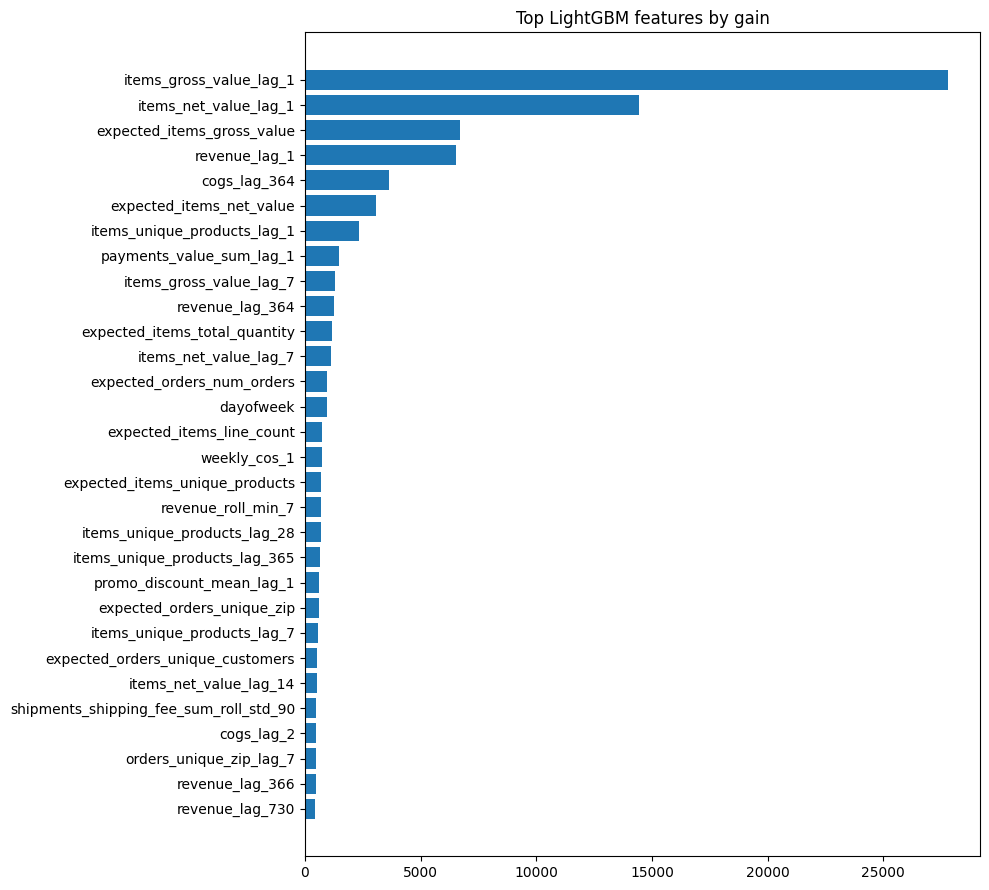

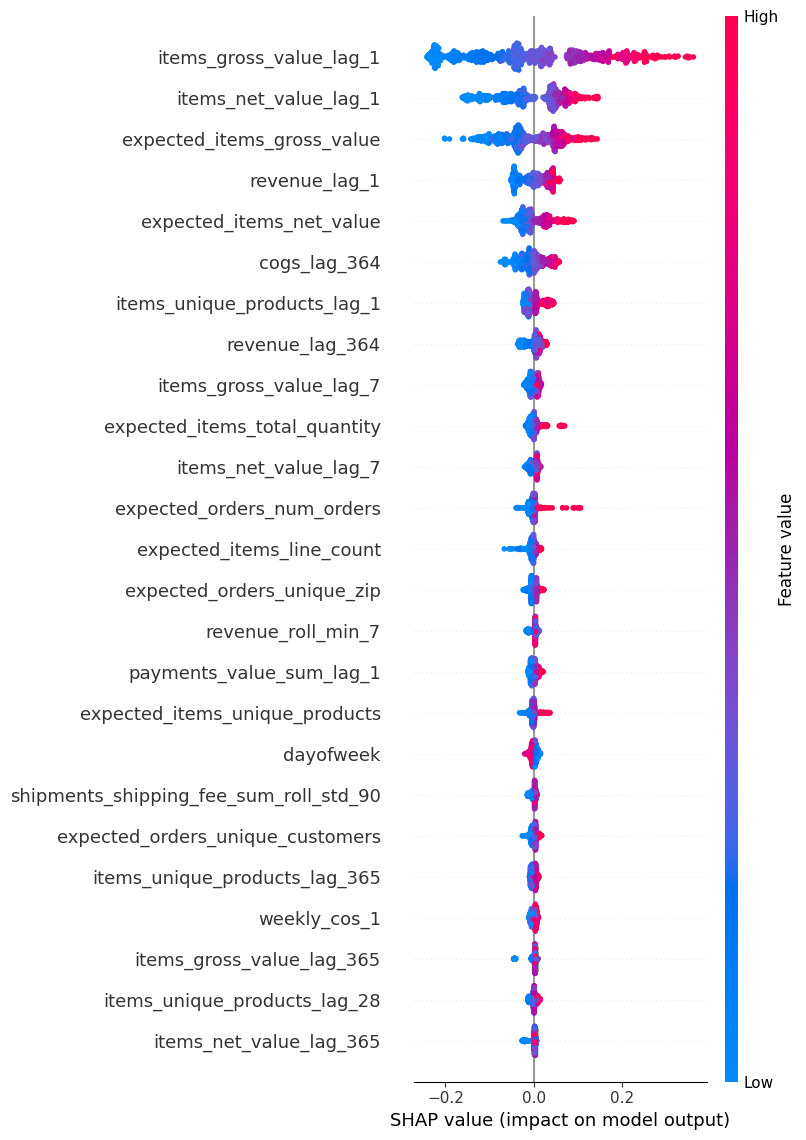

Historical Revenue stats


,history
count,3.833000e+03
mean,4.286584e+06
std,2.624840e+06
min,2.798139e+05
1%,8.450788e+05
5%,1.352929e+06
50%,3.647304e+06
95%,9.398760e+06
99%,1.380199e+07
max,2.090527e+07


Forecast Revenue stats


,forecast
count,5.480000e+02
mean,4.112696e+06
std,1.874069e+06
min,1.364617e+06
1%,1.550760e+06
5%,1.813250e+06
50%,3.691944e+06
95%,7.651979e+06
99%,9.762730e+06
max,1.066820e+07


{'forecast_rows': 548, 'forecast_min': 1364616.63, 'forecast_max': 10668195.74, 'history_p99': 13801990.053599996, 'negative_revenue_count': 0, 'missing_revenue_count': 0}


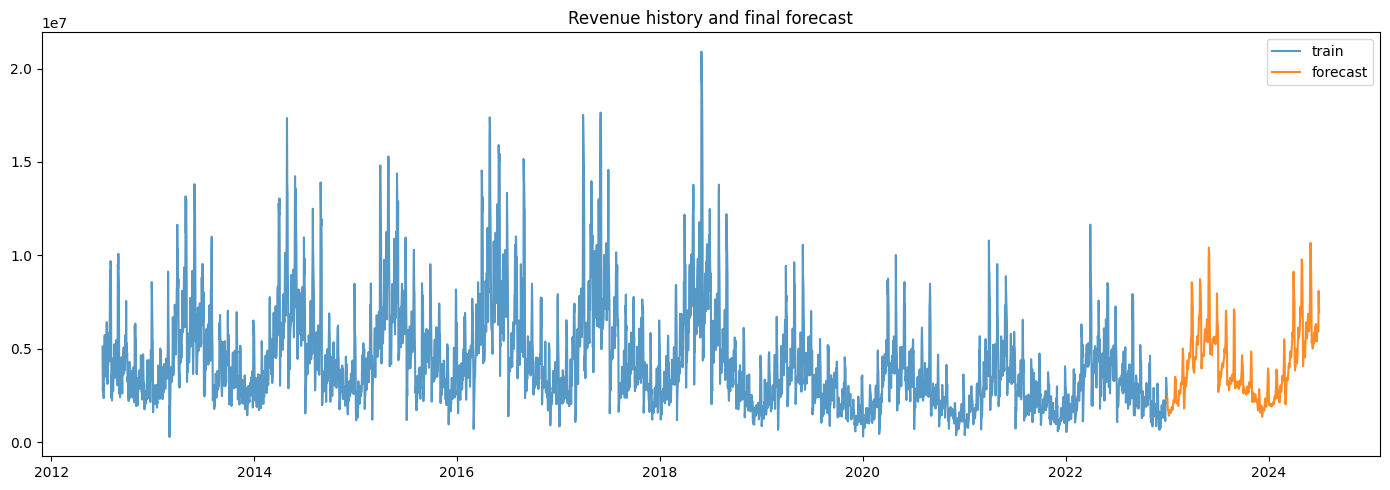

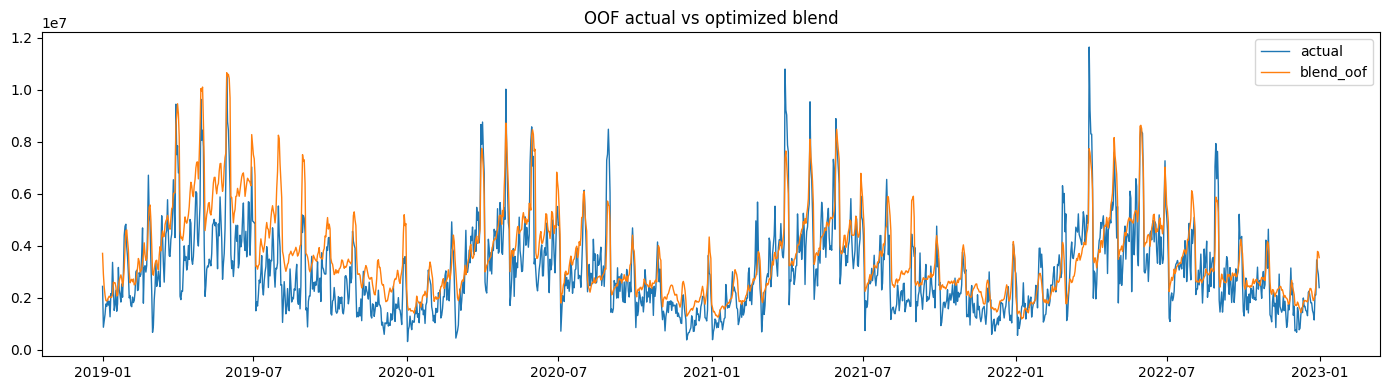

In [ ]:
def find_model(models: List[TrainedModel], prefix: str) -> Optional[TrainedModel]:
    for model in models:
        if model.name.startswith(prefix):
            return model
    return None


lgb_model = find_model(final_models, "lgbm")
if lgb_model is not None and HAS_LGBM:
    booster = lgb_model.model.booster_
    importance = pd.DataFrame({
        "feature": lgb_model.feature_cols,
        "gain": booster.feature_importance(importance_type="gain"),
        "split": booster.feature_importance(importance_type="split"),
    }).sort_values("gain", ascending=False)
    importance.to_csv(REPORT_DIR / "lgbm_feature_importance.csv", index=False)
    display(importance.head(40))
    plt.figure(figsize=(10, 9))
    top = importance.head(30).iloc[::-1]
    plt.barh(top["feature"], top["gain"])
    plt.title("Top LightGBM features by gain")
    plt.tight_layout()
    plt.show()
    if RUN_SHAP and HAS_SHAP:
        try:
            shap_sample = final_train[lgb_model.feature_cols].sample(min(800, len(final_train)), random_state=SEED)
            explainer = shap.TreeExplainer(lgb_model.model)
            shap_values = explainer.shap_values(shap_sample)
            shap.summary_plot(shap_values, shap_sample, max_display=25, show=True)
        except Exception as exc:
            print("SHAP skipped:", exc)

history = sales_raw.sort_values("Date").copy()
print("Historical Revenue stats")
display(history[TARGET].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame("history"))
print("Forecast Revenue stats")
display(submission["Revenue"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame("forecast"))

sanity = {
    "forecast_rows": len(submission),
    "forecast_min": float(submission["Revenue"].min()),
    "forecast_max": float(submission["Revenue"].max()),
    "history_p99": float(history[TARGET].quantile(0.99)),
    "negative_revenue_count": int((submission["Revenue"] < 0).sum()),
    "missing_revenue_count": int(submission["Revenue"].isna().sum()),
}
print(sanity)

plt.figure(figsize=(14, 5))
plt.plot(history["Date"], history[TARGET], label="train", alpha=0.75)
plt.plot(submission["Date"], submission["Revenue"], label="forecast", alpha=0.9)
plt.title("Revenue history and final forecast")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(oof["Date"], oof["actual"], label="actual", linewidth=1)
pred_cols = [c for c in oof.columns if c not in ["Date", "actual", "fold"]]
blend_oof = sum(oof[col].fillna(0).values * blend_weights.get(col, 0.0) for col in pred_cols)
plt.plot(oof["Date"], blend_oof, label="blend_oof", linewidth=1)
plt.title("OOF actual vs optimized blend")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Next leaderboard upgrades

Priority:
1. Install CatBoost and re-run for ensemble diversity.
2. Enable Optuna after the baseline CV is stable.
3. Forecast auxiliary drivers such as sessions/orders with dedicated models instead of seasonal proxy only.
4. Train category/region submodels and reconcile them to total revenue.
5. Inspect `reports/100_TEST/oof_predictions.csv` residual spikes and add event-specific features.
